In [28]:
from dotenv import load_dotenv
load_dotenv() 



True

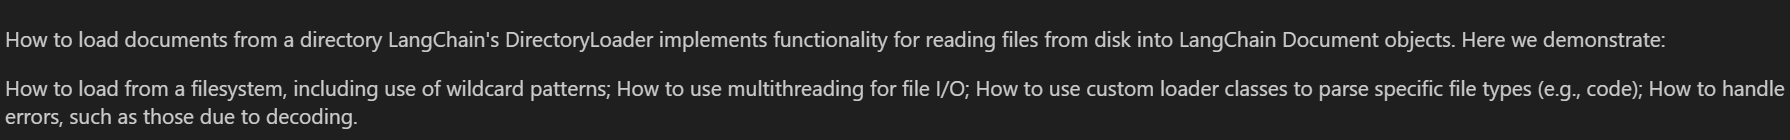

In [29]:
 # from langchain_community.document_loaders import TextLoader

from langchain_community.document_loaders import DirectoryLoader

In [30]:
loader = DirectoryLoader("./data/text/", glob="**/*.txt", loader_cls=TextLoader, show_progress=True, use_multithreading=True)
docs = loader.load()

100%|██████████| 6/6 [00:00<00:00, 217.19it/s]


In [31]:
docs

[Document(metadata={'source': 'data\\text\\artificial-intelligence.txt'}, page_content='# Artificial Intelligence: An Overview\n\n## What is Artificial Intelligence?\n\nArtificial Intelligence (AI) refers to the simulation of human intelligence in machines that are programmed to think and learn like humans. The term encompasses a wide range of technologies and approaches aimed at creating systems capable of performing tasks that typically require human intelligence.\n\n## Key Concepts in AI\n\n### Machine Learning\n\nMachine Learning (ML) is a subset of AI that focuses on the development of algorithms and statistical models that enable computer systems to improve their performance on a specific task through experience. Key approaches include:\n\n1. Supervised Learning\n2. Unsupervised Learning\n3. Reinforcement Learning\n\n### Deep Learning\n\nDeep Learning is a subset of machine learning based on artificial neural networks with multiple layers. It has been particularly successful in a

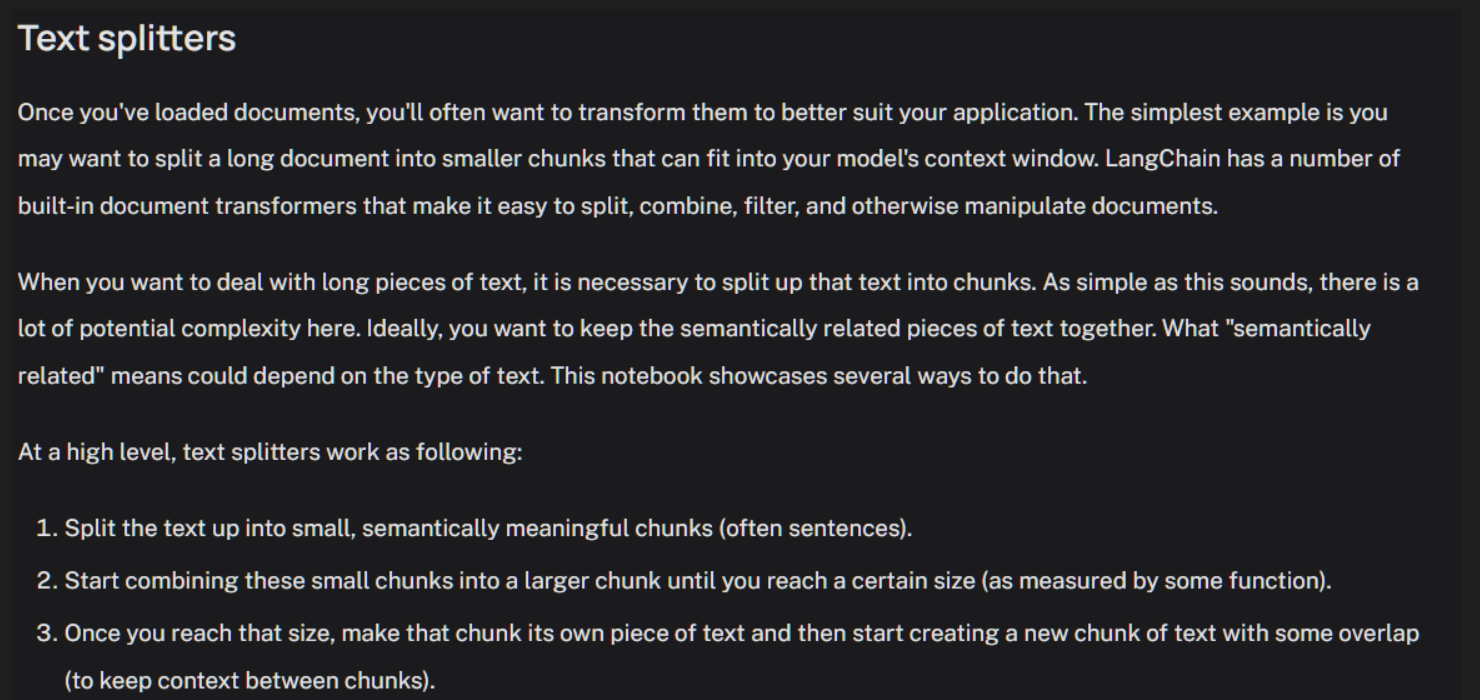

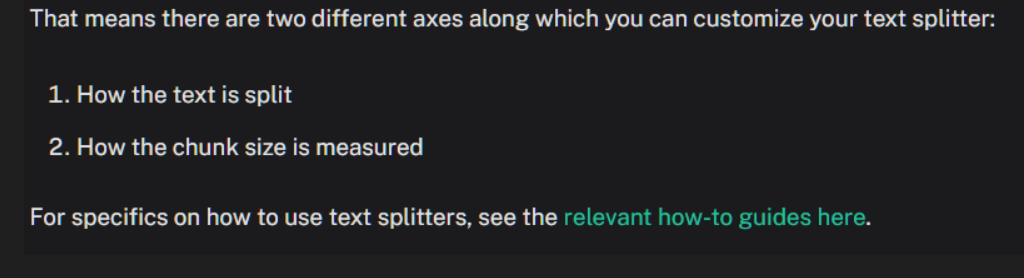

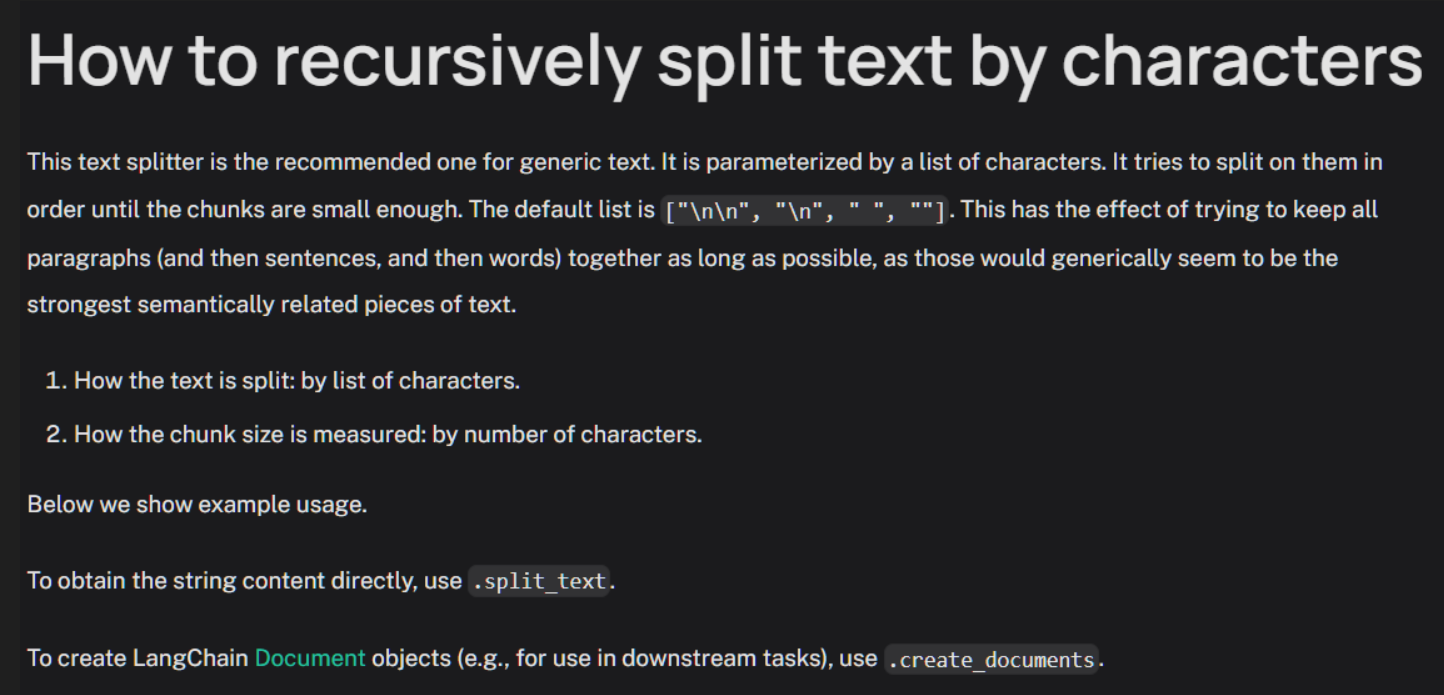

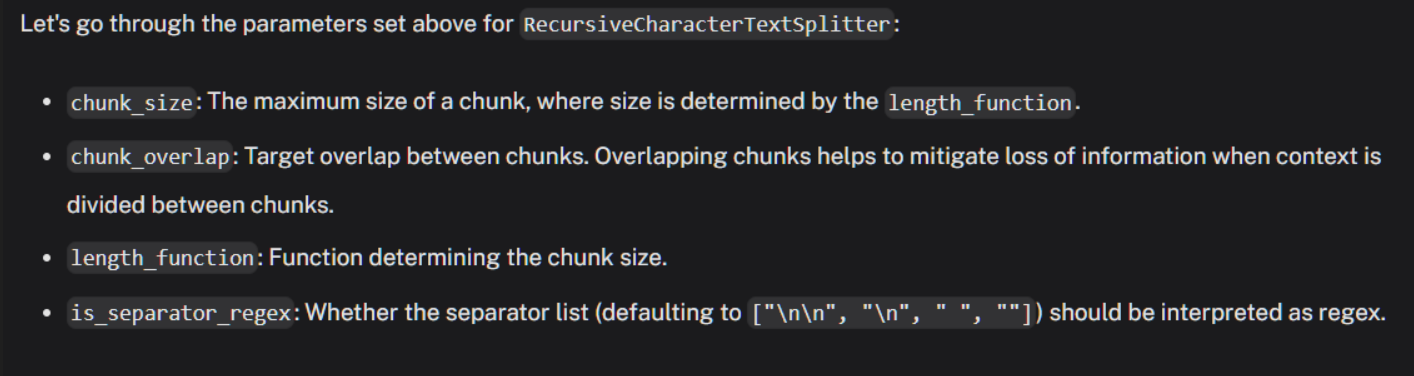

In [32]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Load example document
with open("./data/text/artificial-intelligence.txt") as f:
    ai = f.read()

text_splitter = RecursiveCharacterTextSplitter(
    # Set a really small chunk size, just to show.
    chunk_size=100,
    chunk_overlap=20,
    length_function=len,
    is_separator_regex=False,
)
texts = text_splitter.create_documents([ai])
print(texts[0])


page_content='# Artificial Intelligence: An Overview

## What is Artificial Intelligence?'


In [33]:
print(len(texts))

39


In [34]:
texts

[Document(metadata={}, page_content='# Artificial Intelligence: An Overview\n\n## What is Artificial Intelligence?'),
 Document(metadata={}, page_content='Artificial Intelligence (AI) refers to the simulation of human intelligence in machines that are'),
 Document(metadata={}, page_content='machines that are programmed to think and learn like humans. The term encompasses a wide range of'),
 Document(metadata={}, page_content='a wide range of technologies and approaches aimed at creating systems capable of performing tasks'),
 Document(metadata={}, page_content='of performing tasks that typically require human intelligence.'),
 Document(metadata={}, page_content='## Key Concepts in AI\n\n### Machine Learning'),
 Document(metadata={}, page_content='Machine Learning (ML) is a subset of AI that focuses on the development of algorithms and'),
 Document(metadata={}, page_content='of algorithms and statistical models that enable computer systems to improve their performance on a'),
 Document(

In [35]:
text_splitter.split_text(ai)[:2]

['# Artificial Intelligence: An Overview\n\n## What is Artificial Intelligence?',
 'Artificial Intelligence (AI) refers to the simulation of human intelligence in machines that are']

In [37]:
print(docs[0].page_content[:100])

# Artificial Intelligence: An Overview

## What is Artificial Intelligence?

Artificial Intelligence


In [46]:
loaders = [
    TextLoader("./data/text/artificial-intelligence.txt"),
    TextLoader("./data/text/climate-change.txt"),
]
docs = []
for loader in loaders:
    docs.extend(loader.load())

In [39]:
#%pip install os
import os
google_api = os.getenv("GOOGLE_API_KEY")

In [41]:
import getpass
import os

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Provide your Google API key here")

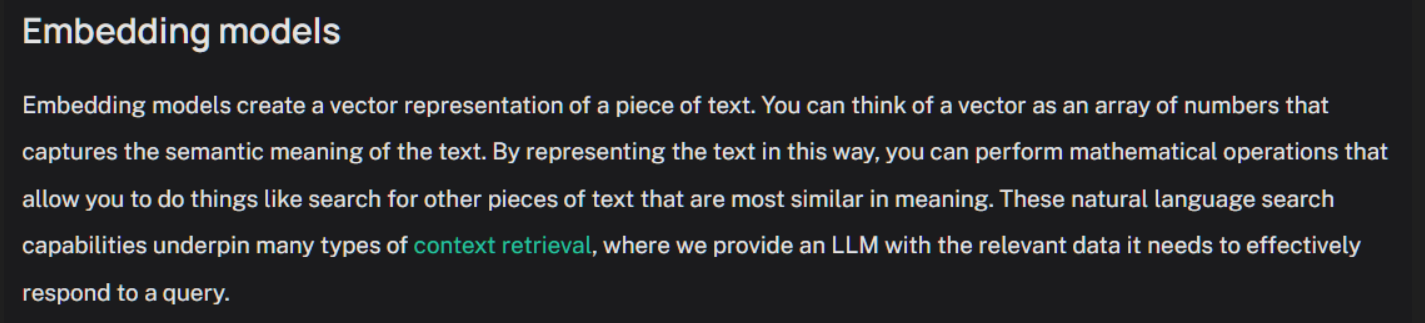

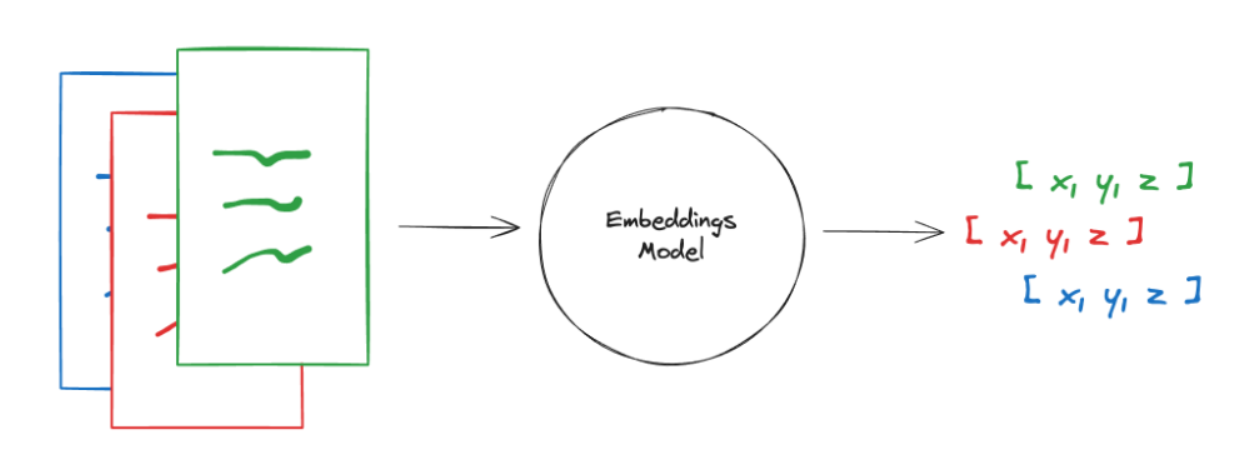

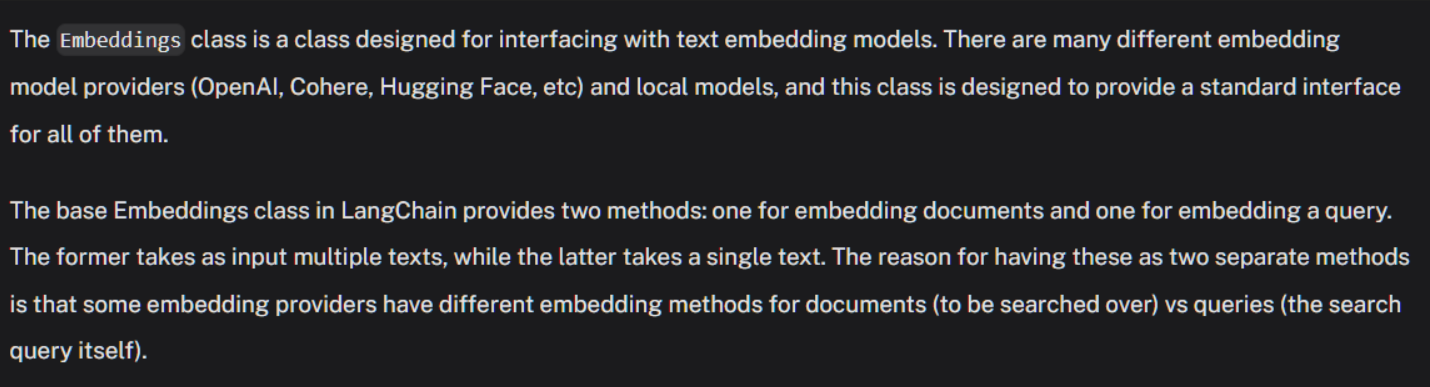

In [43]:
pip install langchain_google_genai

  Using cached langchain_google_genai-2.0.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached google_generativeai-0.8.3-py3-none-any.whl.metadata (3.9 kB)
  Using cached google_ai_generativelanguage-0.6.10-py3-none-any.whl.metadata (5.6 kB)
  Using cached google_auth-2.35.0-py2.py3-none-any.whl.metadata (4.7 kB)
  Using cached protobuf-5.28.2-cp310-abi3-win_amd64.whl.metadata (592 bytes)
  Using cached proto_plus-1.24.0-py3-none-any.whl.metadata (2.2 kB)
  Using cached googleapis_common_protos-1.65.0-py2.py3-none-any.whl.metadata (1.5 kB)
  Using cached cachetools-5.5.0-py3-none-any.whl.metadata (5.3 kB)
  Using cached pyasn1_modules-0.4.1-py3-none-any.whl.metadata (3.5 kB)
  Using cached rsa-4.9-py3-none-any.whl.metadata (4.2 kB)
  Using cached httplib2-0.22.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached google_auth_httplib2-0.2.0-py2.py3-none-any.whl.metadata (2.2 kB)
  Using cached uritemplate-4.1.1-py2.py3-none-any.whl.metadata (2.9 kB)
  Using cached pyasn1-0.6.1-py3-none-any

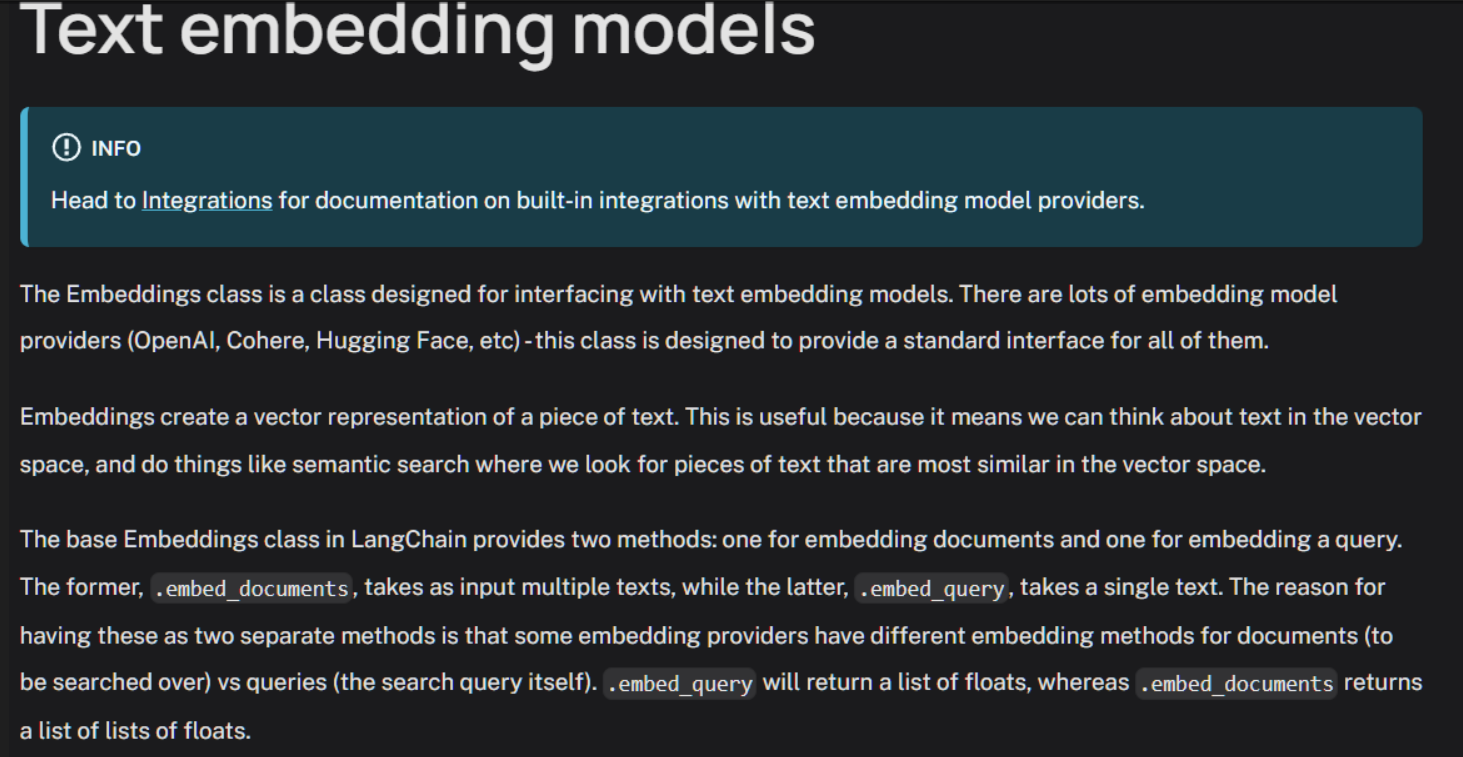

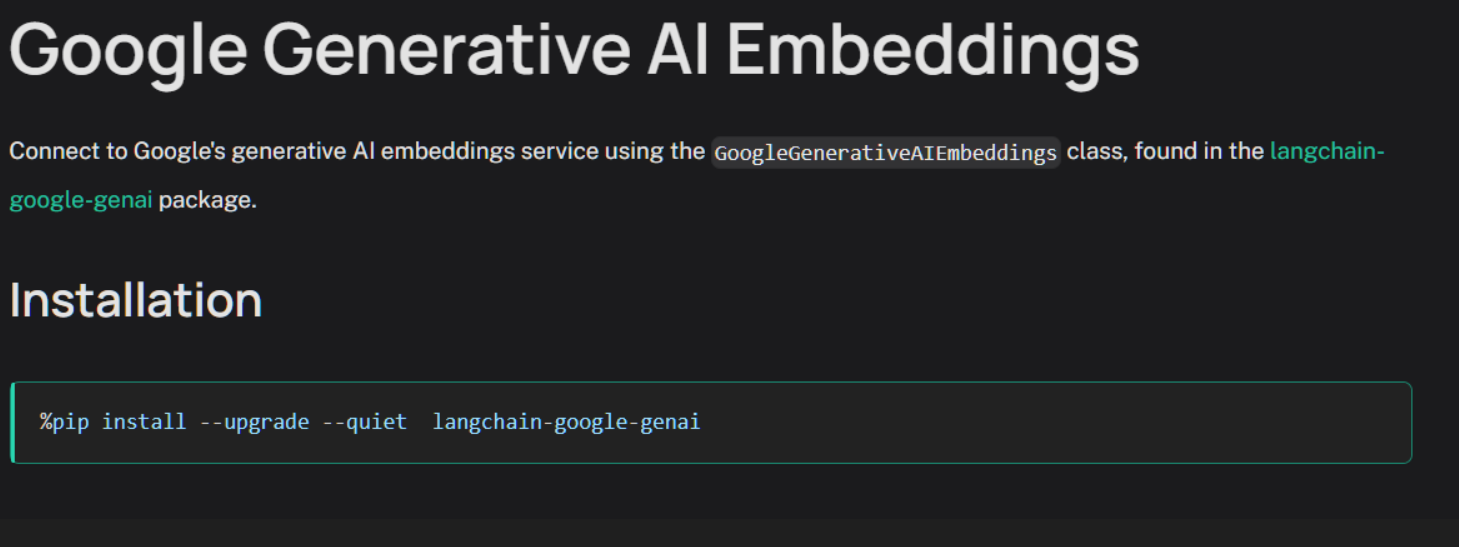

In [44]:
from langchain.storage import InMemoryStore
#from langchain_chroma import Chroma
from langchain_community.document_loaders import TextLoader
#from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings



embeddings = GoogleGenerativeAIEmbeddings(model="models/embedding-001")

c:\Users\tmaity\OneDrive - DXC Production\Desktop\AI-ML-Sam\Jupyter\RAG\LangChain\demo-venv-1\demovenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [50]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings



embeddings = GoogleGenerativeAIEmbeddings(model="models/embedding-001")
vector = embeddings.embed_query("hello, world!")
vector[:5]

[0.05168594419956207,
 -0.030764883384108543,
 -0.03062233328819275,
 -0.02802734449505806,
 0.01813092641532421]

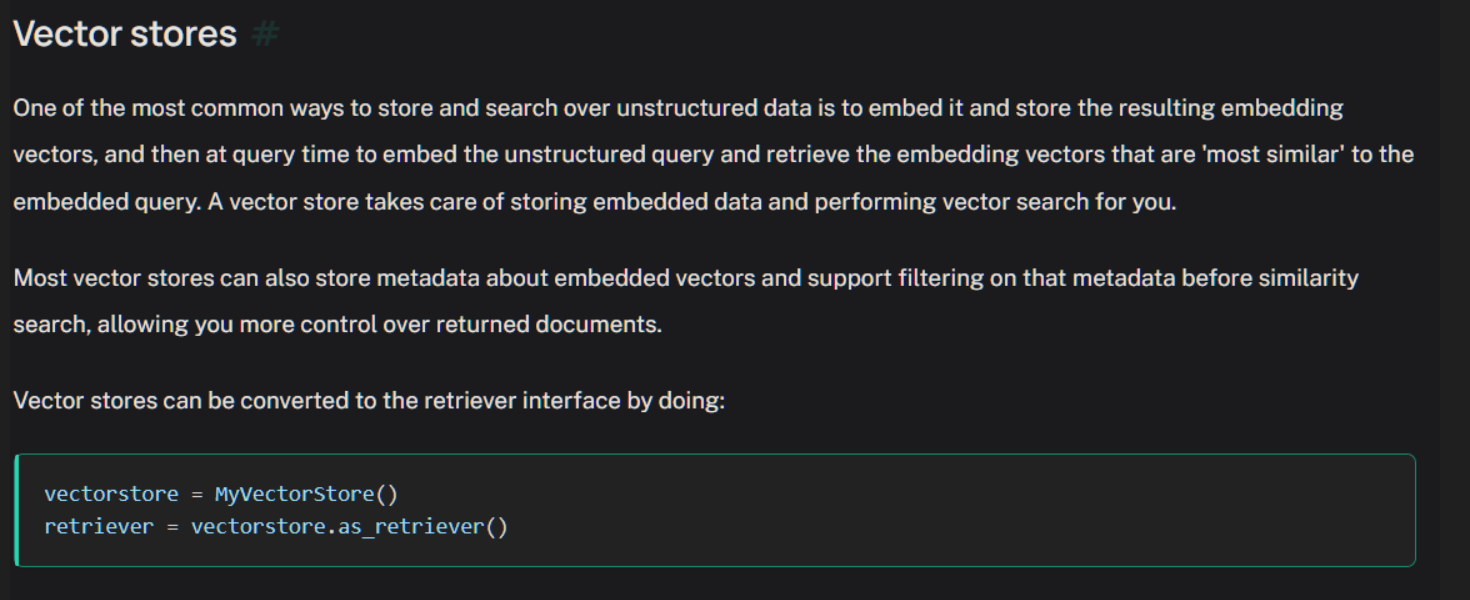

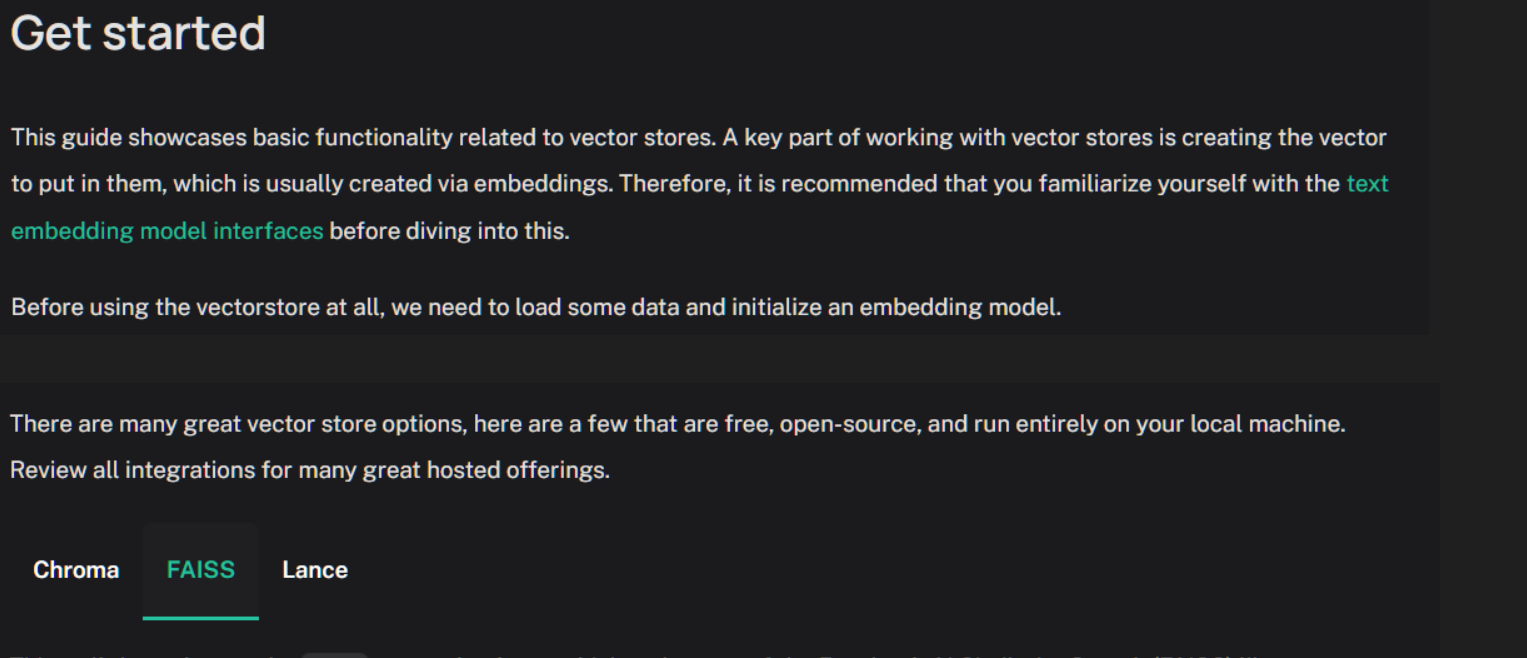

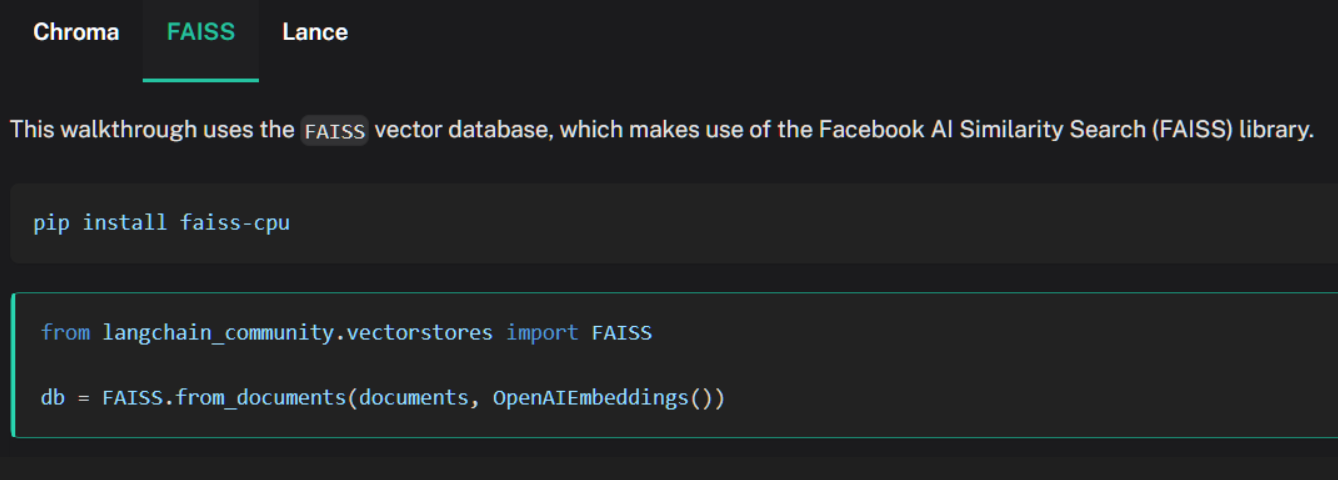

In [52]:
from langchain_community.vectorstores import FAISS

In [53]:

vectorstore = FAISS.from_documents(texts, embeddings)

In [58]:
retriever = vectorstore.as_retriever()

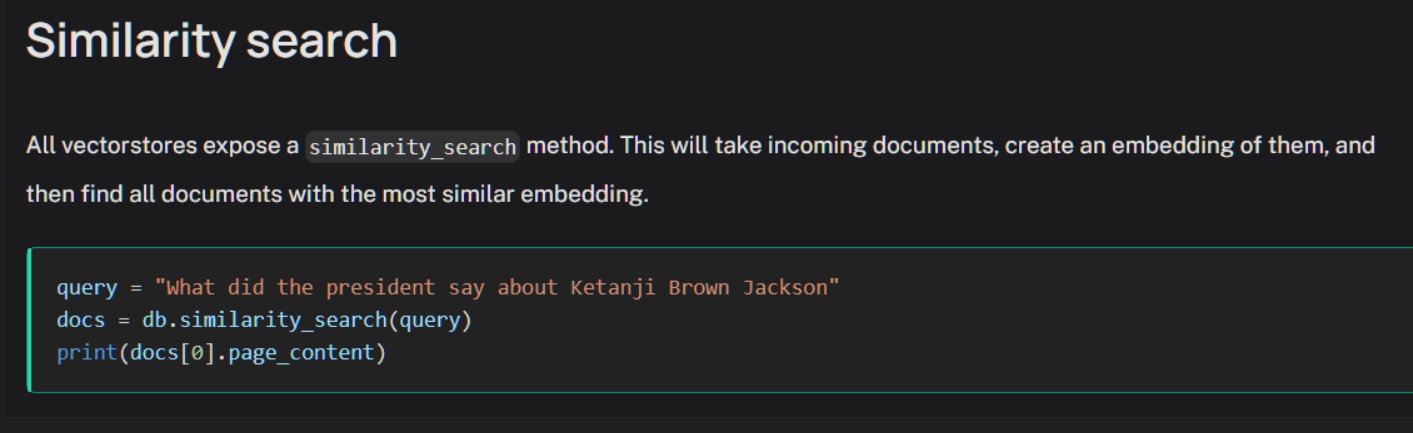

In [61]:
query = "what is AI?"

docs = vectorstore.similarity_search(query, k=2)

print(docs)

[Document(metadata={}, page_content='Artificial Intelligence (AI) refers to the simulation of human intelligence in machines that are'), Document(metadata={}, page_content='# Artificial Intelligence: An Overview\n\n## What is Artificial Intelligence?')]


In [62]:
print(docs[0].page_content)

Artificial Intelligence (AI) refers to the simulation of human intelligence in machines that are


In [63]:
docs_score = vectorstore.similarity_search_with_score(query)
print(docs_score)

[(Document(metadata={}, page_content='Artificial Intelligence (AI) refers to the simulation of human intelligence in machines that are'), 0.5894438), (Document(metadata={}, page_content='# Artificial Intelligence: An Overview\n\n## What is Artificial Intelligence?'), 0.6045767), (Document(metadata={}, page_content='## Key Concepts in AI\n\n### Machine Learning'), 0.6364004), (Document(metadata={}, page_content='of performing tasks that typically require human intelligence.'), 0.67032164)]


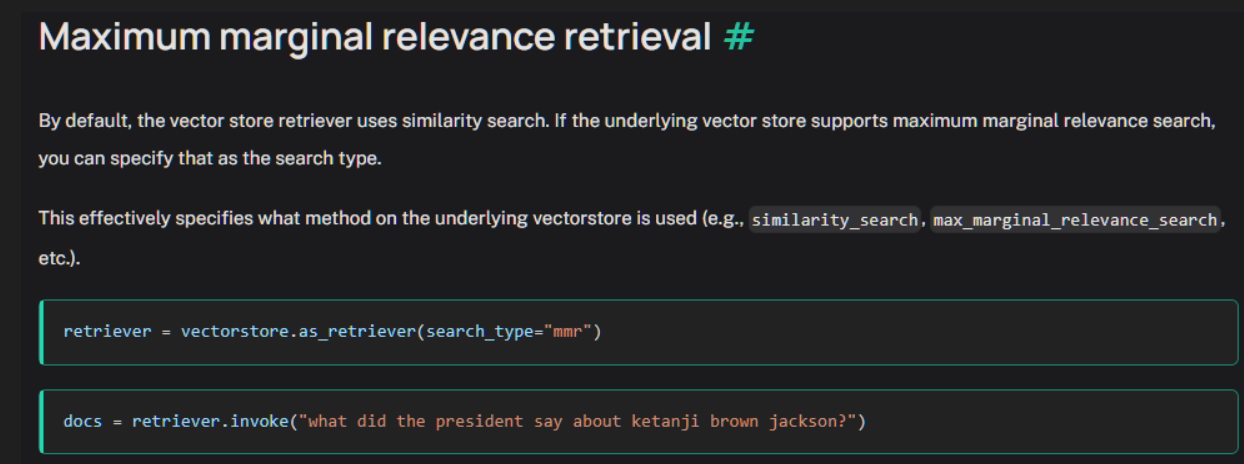

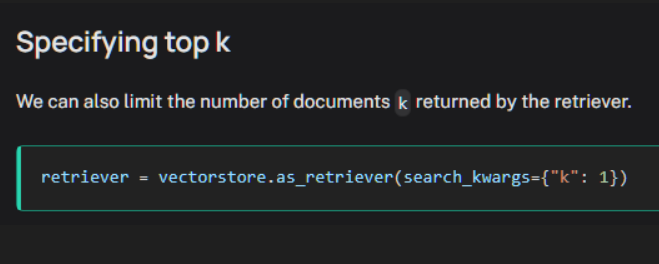

In [64]:
retriever = vectorstore.as_retriever(search_type='mmr', search_kwargs={"k":2})
docs = retriever.invoke(query)
docs

[Document(metadata={}, page_content='Artificial Intelligence (AI) refers to the simulation of human intelligence in machines that are'),
 Document(metadata={}, page_content='3. Job displacement due to automation\n4. Accountability and transparency in AI decision-making')]

### ROUGH ####

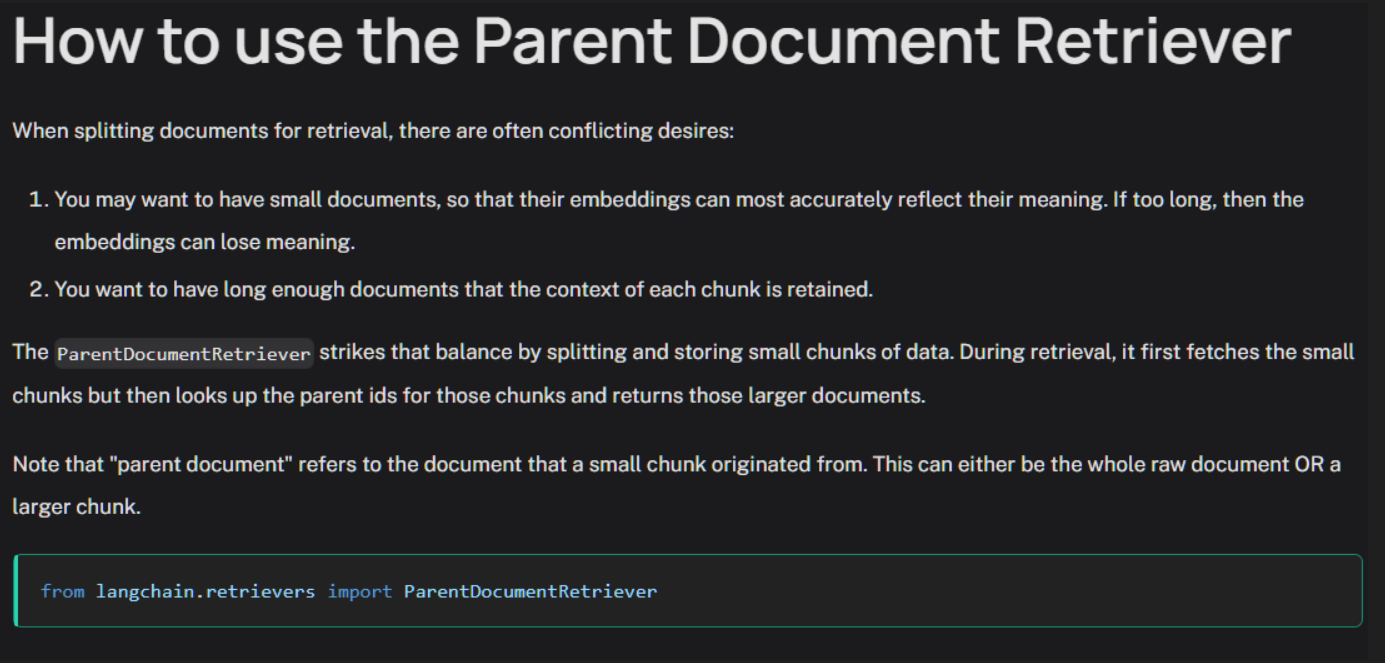

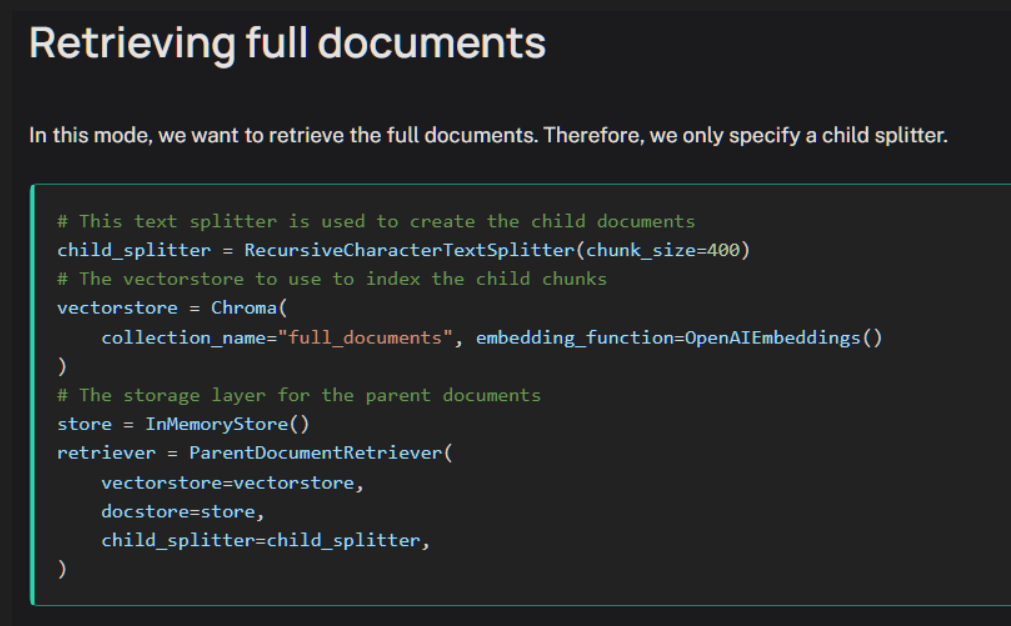

## for more info go to https://python.langchain.com/docs/how_to/parent_document_retriever/#retrieving-full-documents

In [27]:
### Google generaative AI Embedding
# %pip install --upgrade --quiet  langchain-google-genai

### LLM Call ###

In [55]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-1.5-pro",temperature=0.3, max_tokens=500)

### PromptTemplate ###

In [56]:
from langchain.chains import create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate

system_prompt = (
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer "
    "the question. If you don't know the answer, say that you "
    "don't know. Use three sentences maximum and keep the "
    "answer concise."
    "\n\n"
    "{context}"
)

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        ("human", "{input}"),
    ]
)

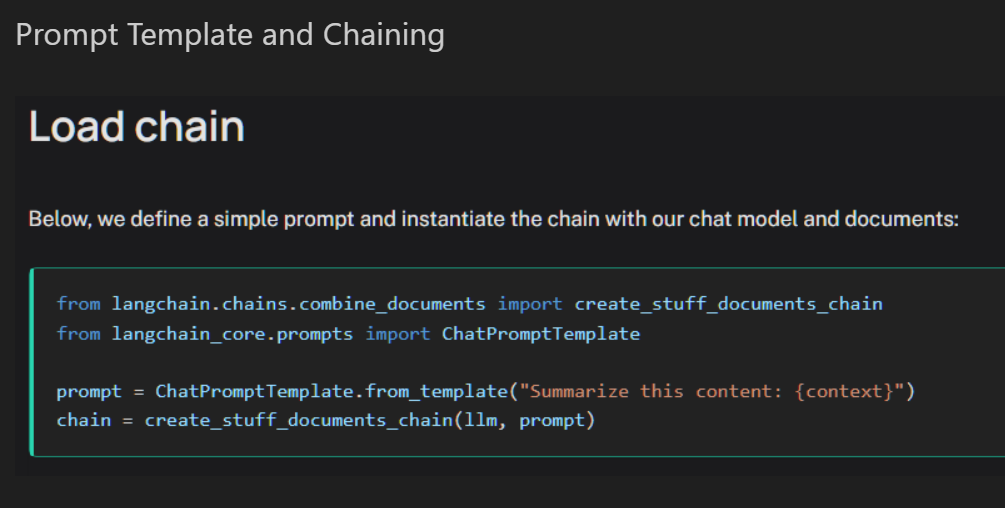

### "Building a Retrieval-Augmented Generation (RAG) Pipeline with Question-Answer Chain in LangChain" ###

In [59]:
question_answer_chain = create_stuff_documents_chain(llm, prompt)
rag_chain = create_retrieval_chain(retriever, question_answer_chain)

In [60]:
response = rag_chain.invoke({"input": "what is AI?"})
print(response["answer"])

Artificial intelligence (AI) involves creating intelligent agents. These agents are systems that can reason, learn, and act autonomously.  AI aims to simulate human intelligence in machines, enabling them to perform tasks that usually require human cognition. 

